# Визуализация в языке программирования Python

Цель: ознакомится с различными библиотеками визуализации данных
(matplotlib, plotly, TSNE, UMAP) и особенностями работы с ними в среде
программирования Python.

## Задание №1

### Загрузка датасета

In [2]:
import kagglehub
import pandas as pd
import os


path = kagglehub.dataset_download("ekibee/car-sales-information")

file_path = os.path.join(path, "all_regions.csv")
df = pd.read_csv(file_path)

## Задание №2

### Первые N строк

In [3]:
n = 5
df.head(n)

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,link,description,parse_date
0,Volkswagen,Golf,Хэтчбек 5 дв.,Серебристый,Бензин,NaN,240000.0,Механика,101.0,280000,NaN,NaN,NaN,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/volkswagen/golf/5001300...,101 л.с. люк не течёт. Документы в порядке. Со...,2023-05-02 01:00:00
1,Лада,1111 Ока,Хэтчбек 3 дв.,Фиолетовый,Бензин,1996.0,37000.0,Механика,33.0,95000,0.6 MT 11113,ВАЗ-11113,0.7 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/oka/50378140.html,"Ваз Ока Год: 2003 Цвет: Баклажан, в ПТС так и ...",2023-05-02 20:00:00
2,Toyota,Funcargo,Хэтчбек 5 дв.,Серебристый,Бензин,2002.0,295000.0,АКПП,87.0,380000,1.3 J,2NZ-FE,1.3 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/toyota/funcargo/5037751...,ХОРОШЕЕ СОСТОЯНИЕ. замена комплекта грм и помп...,2023-05-02 20:00:00
3,Лада,Гранта,Лифтбек,Серый,Бензин,2018.0,16000.0,Механика,106.0,795000,1.6 MT Comfort,ВАЗ-21127,1.6 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/granta/50382492.html,"Автомобиль в отличном техническом состоянии, н...",2023-05-02 23:00:00
4,Лада,Нива Легенд,Джип 3 дв.,Зеленый,Бензин,NaN,NaN,Механика,83.0,1022900,NaN,NaN,NaN,2023-04-02 00:00:00,Яблоновский,https://yablonovskiy.drom.ru/lada/niva_legend/...,Модель: Нива Легенд Комплектация: LADA (ВАЗ) N...,2023-05-02 20:00:00


### Информация о датасете

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294757 entries, 0 to 1294756
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   brand                 1294757 non-null  object 
 1   name                  1294757 non-null  object 
 2   bodyType              1294757 non-null  object 
 3   color                 1257029 non-null  object 
 4   fuelType              1289815 non-null  object 
 5   year                  724644 non-null   float64
 6   mileage               771799 non-null   float64
 7   transmission          1289563 non-null  object 
 8   power                 1273353 non-null  float64
 9   price                 1294757 non-null  int64  
 10  vehicleConfiguration  724647 non-null   object 
 11  engineName            720976 non-null   object 
 12  engineDisplacement    717625 non-null   object 
 13  date                  1294757 non-null  object 
 14  location              1294757 non-

### Дубликаты

In [5]:
df.duplicated().sum()

np.int64(0)

### Пустые значения

In [6]:
df.isna().sum()

brand                        0
name                         0
bodyType                     0
color                    37728
fuelType                  4942
year                    570113
mileage                 522958
transmission              5194
power                    21404
price                        0
vehicleConfiguration    570110
engineName              573781
engineDisplacement      577132
date                         0
location                     0
link                         0
description              40352
parse_date                   0
dtype: int64

### Удаление строк с пустыми значениями

In [7]:
df.dropna(how="any", inplace=True, ignore_index=True)
df.isna().sum()

brand                   0
name                    0
bodyType                0
color                   0
fuelType                0
year                    0
mileage                 0
transmission            0
power                   0
price                   0
vehicleConfiguration    0
engineName              0
engineDisplacement      0
date                    0
location                0
link                    0
description             0
parse_date              0
dtype: int64

In [8]:
df.shape

(399192, 18)

### Удаление ненужных столбцов, работа над типами данных

In [9]:
df.drop(columns=["link", "parse_date"], inplace=True)
df.head()

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,description
0,Лада,1111 Ока,Хэтчбек 3 дв.,Фиолетовый,Бензин,1996.0,37000.0,Механика,33.0,95000,0.6 MT 11113,ВАЗ-11113,0.7 LTR,2023-04-02 00:00:00,Майкоп,"Ваз Ока Год: 2003 Цвет: Баклажан, в ПТС так и ..."
1,Toyota,Funcargo,Хэтчбек 5 дв.,Серебристый,Бензин,2002.0,295000.0,АКПП,87.0,380000,1.3 J,2NZ-FE,1.3 LTR,2023-04-02 00:00:00,Майкоп,ХОРОШЕЕ СОСТОЯНИЕ. замена комплекта грм и помп...
2,Лада,Гранта,Лифтбек,Серый,Бензин,2018.0,16000.0,Механика,106.0,795000,1.6 MT Comfort,ВАЗ-21127,1.6 LTR,2023-04-02 00:00:00,Майкоп,"Автомобиль в отличном техническом состоянии, н..."
3,Chevrolet,Niva,Джип 5 дв.,Зеленый,Бензин,2002.0,220000.0,Механика,80.0,450000,1.7 MT L,ВАЗ-2123,1.7 LTR,2023-04-03 00:00:00,Майкоп,Продам шевика в хорошем состоянии. Гнили нет о...
4,Лада,2114 Самара,Хэтчбек 5 дв.,Черный,Бензин,2007.0,185000.0,Механика,81.0,120000,1.6 MT 21144-22-010,ВАЗ-11183,1.6 LTR,2023-04-03 00:00:00,Майкоп,"в хорошем состоянии.гнили нет,много чего новог..."


### Приведение типов данных

In [10]:
df["year"] = df["year"].astype("int64")
df["mileage"] = df["mileage"].astype("int64")
df["power"] = df["power"].astype("int64")
df["engineDisplacement"] = df["engineDisplacement"].str.rstrip("LTR").astype("float64")
df["date"] = df["date"].astype("datetime64[ns]")
df.head()

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,description
0,Лада,1111 Ока,Хэтчбек 3 дв.,Фиолетовый,Бензин,1996,37000,Механика,33,95000,0.6 MT 11113,ВАЗ-11113,0.7,2023-04-02,Майкоп,"Ваз Ока Год: 2003 Цвет: Баклажан, в ПТС так и ..."
1,Toyota,Funcargo,Хэтчбек 5 дв.,Серебристый,Бензин,2002,295000,АКПП,87,380000,1.3 J,2NZ-FE,1.3,2023-04-02,Майкоп,ХОРОШЕЕ СОСТОЯНИЕ. замена комплекта грм и помп...
2,Лада,Гранта,Лифтбек,Серый,Бензин,2018,16000,Механика,106,795000,1.6 MT Comfort,ВАЗ-21127,1.6,2023-04-02,Майкоп,"Автомобиль в отличном техническом состоянии, н..."
3,Chevrolet,Niva,Джип 5 дв.,Зеленый,Бензин,2002,220000,Механика,80,450000,1.7 MT L,ВАЗ-2123,1.7,2023-04-03,Майкоп,Продам шевика в хорошем состоянии. Гнили нет о...
4,Лада,2114 Самара,Хэтчбек 5 дв.,Черный,Бензин,2007,185000,Механика,81,120000,1.6 MT 21144-22-010,ВАЗ-11183,1.6,2023-04-03,Майкоп,"в хорошем состоянии.гнили нет,много чего новог..."


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399192 entries, 0 to 399191
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   brand                 399192 non-null  object        
 1   name                  399192 non-null  object        
 2   bodyType              399192 non-null  object        
 3   color                 399192 non-null  object        
 4   fuelType              399192 non-null  object        
 5   year                  399192 non-null  int64         
 6   mileage               399192 non-null  int64         
 7   transmission          399192 non-null  object        
 8   power                 399192 non-null  int64         
 9   price                 399192 non-null  int64         
 10  vehicleConfiguration  399192 non-null  object        
 11  engineName            399192 non-null  object        
 12  engineDisplacement    399192 non-null  float64       
 13 

## Задание №3

In [12]:
import plotly.graph_objs as go

year_count = df['year'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(go.Bar(
    x=year_count.index,
    y=year_count.values,
    marker=dict(
        color=year_count.values,
        coloraxis="coloraxis",
        line=dict(color='black', width=2)
    )
))
fig.update_layout(
    title={
        'text': 'Количество автомобилей по годам выпуска',
        'font': {'size': 20},
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'y': 0.95
    },
    xaxis_title='Год выпуска',
    yaxis_title='Количество автомобилей',
    xaxis=dict(
        title_font_size=16,
        tickfont_size=14,
        tickangle=315,
        showgrid=True,
        gridcolor='ivory',
        gridwidth=2
    ),
    yaxis=dict(
        title_font_size=16,
        tickfont_size=14,
        showgrid=True,
        gridcolor='ivory',
        gridwidth=2
    ),
    height=700,
    width=None,
    margin=dict(l=0, r=0, t=0, b=0),
    coloraxis=dict(colorscale='Viridis')
)
fig.show()

## Задание №4

In [13]:
fig_pie = go.Figure()

labels = year_count.loc[2010:2020].index
values = year_count.loc[2010:2020].values


fig_pie.add_trace(go.Pie(labels=labels, values=values,
                         pull=[0, 0.3, 0, 0, 0, 0, 0.25, 0, 0, 0], 
                         hole=.3, 
                         marker=dict(
        line=dict(color='black', width=2)
    ),
    textinfo='percent+label',
    ))

fig_pie.update_layout(
    title={
        'text': 'Распределение автомобилей по годам выпуска c 2010 по 2020 год',
        'font': {'size': 20},
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'y': 0.95
    },
    height=700,
    width=None,
    margin=dict(l=50, r=50, t=100, b=50),
    legend=dict(
        font=dict(size=14),
        orientation='v',
        yanchor='middle',
        y=0.5,
        xanchor='left',
        x=1.05
    )
)

fig_pie.show()

## Задание №5

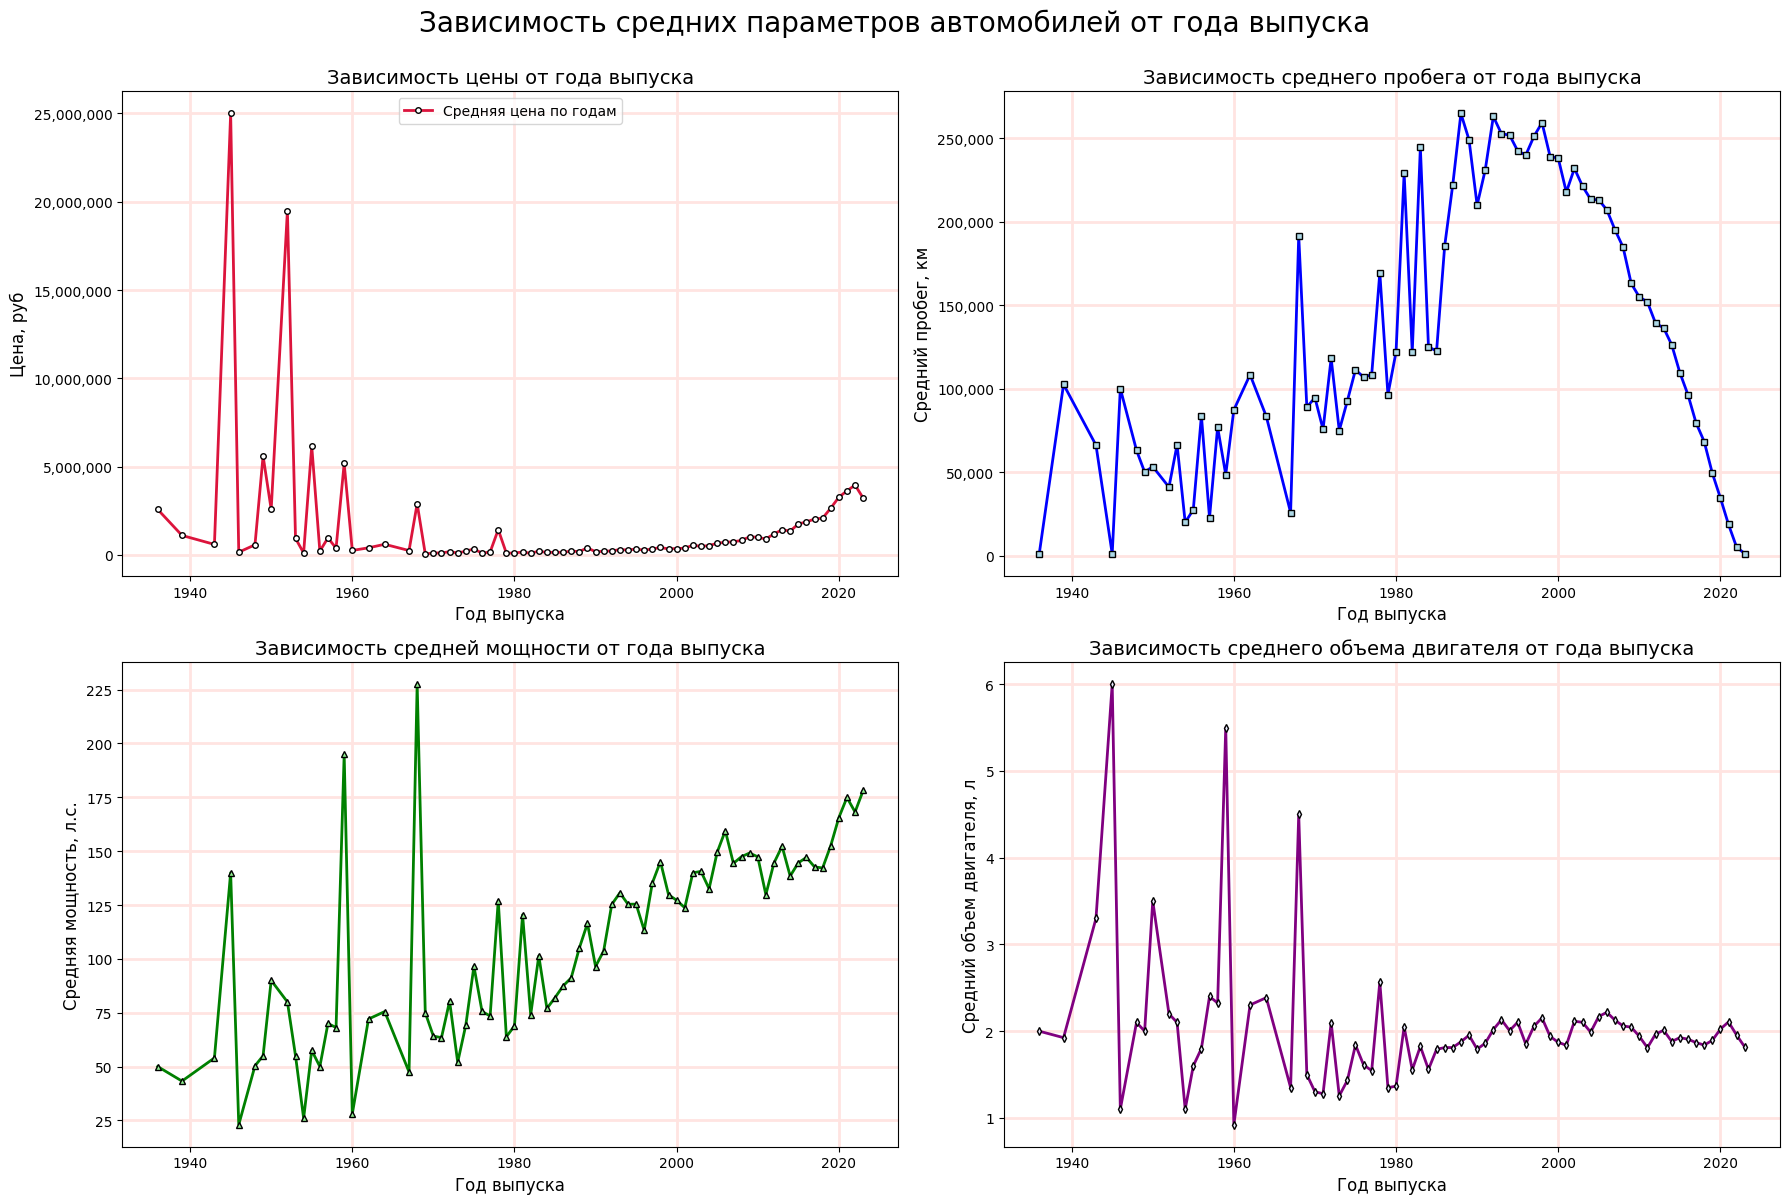

In [48]:
import matplotlib.pyplot as plt


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Зависимость средних параметров автомобилей от года выпуска', fontsize=20, y=1)

yearly_avg = df.groupby('year').agg({
    'price': 'mean',
    'mileage': 'mean',
    'power': 'mean',
    'engineDisplacement': 'mean'
}).reset_index()

ax1.plot(yearly_avg["year"], yearly_avg["price"], 
         marker='o', linewidth=2, markersize=4,
         color='crimson', markerfacecolor='white',
         markeredgecolor='black', markeredgewidth=1,
         label='Средняя цена по годам')
ax1.set_xlabel('Год выпуска', fontsize=12)
ax1.set_ylabel('Цена, руб', fontsize=12)
ax1.set_title('Зависимость цены от года выпуска', fontsize=14)
ax1.grid(True, color='mistyrose', linewidth=2)
ax1.legend(loc = 'upper center')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

ax2.plot(yearly_avg["year"], yearly_avg["mileage"], 
         marker='s', linewidth=2, markersize=4,
         color='blue', markerfacecolor='lightblue',
         markeredgecolor='black', markeredgewidth=1,
         label = "Средний пробег по годам")
ax2.set_xlabel('Год выпуска', fontsize=12)
ax2.set_ylabel('Средний пробег, км', fontsize=12)
ax2.set_title('Зависимость среднего пробега от года выпуска', fontsize=14)
ax2.grid(True, color='mistyrose', linewidth=2)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

ax3.plot(yearly_avg["year"], yearly_avg["power"], 
         marker='^', linewidth=2, markersize=4,
         color='green', markerfacecolor='lightgreen',
         markeredgecolor='black', markeredgewidth=1,
         label = "Средняя мощность по годам")
ax3.set_xlabel('Год выпуска', fontsize=12)
ax3.set_ylabel('Средняя мощность, л.с.', fontsize=12)
ax3.set_title('Зависимость средней мощности от года выпуска', fontsize=14)
ax3.grid(True, color='mistyrose', linewidth=2)

ax4.plot(yearly_avg["year"], yearly_avg["engineDisplacement"], 
         marker='d', linewidth=2, markersize=4,
         color='purple', markerfacecolor='lavender',
         markeredgecolor='black', markeredgewidth=1,
         label = "Средний объем двигателя по годам")
ax4.set_xlabel('Год выпуска', fontsize=12)
ax4.set_ylabel('Средний объем двигателя, л', fontsize=12)
ax4.set_title('Зависимость среднего объема двигателя от года выпуска', fontsize=14)
ax4.grid(True, color='mistyrose', linewidth=2)

plt.tight_layout()
plt.show()

## Задание №6

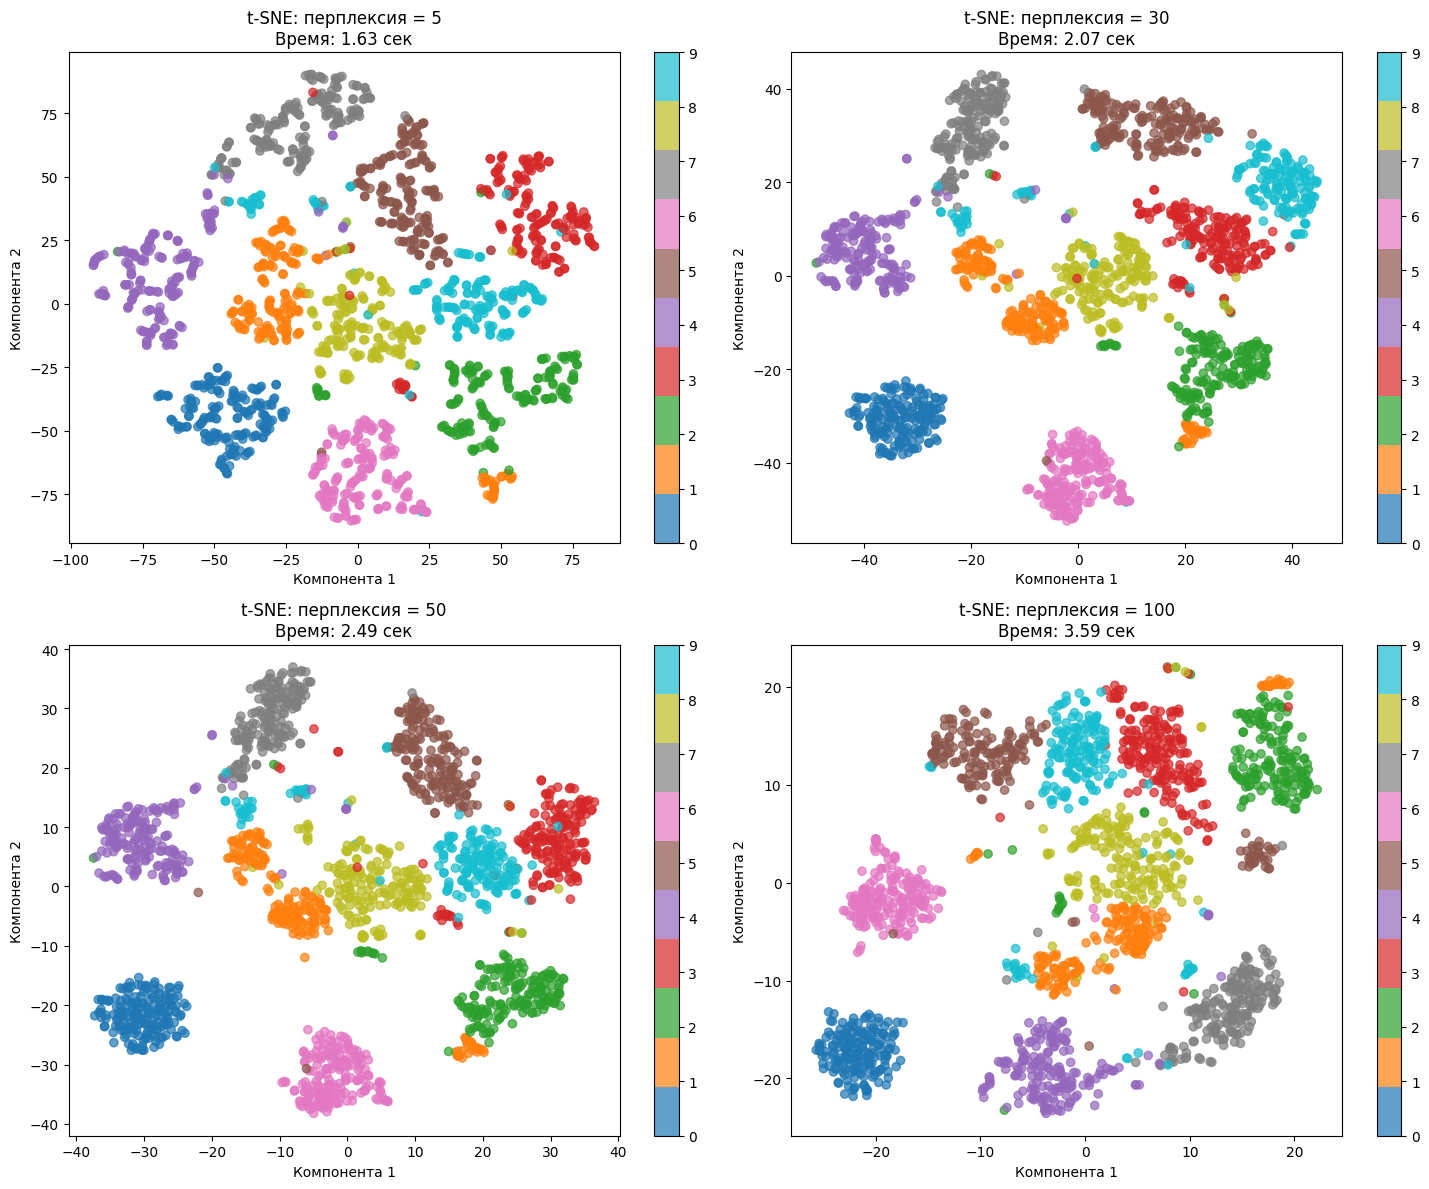

In [55]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import time


digits = datasets.load_digits()
X = digits.data
y = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

perplexities = [5, 30, 50, 100]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, perplexity in enumerate(perplexities):
    start_time = time.time()
    tsne = TSNE(n_components=2, 
                perplexity=perplexity, 
                random_state=42, 
                max_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)
    tsne_time = time.time() - start_time
    
    scatter = axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                             c=y, cmap='tab10', alpha=0.7)
    axes[i].set_title(f't-SNE: перплексия = {perplexity}\nВремя: {tsne_time:.2f} сек')
    axes[i].set_xlabel('Компонента 1')
    axes[i].set_ylabel('Компонента 2')
    plt.colorbar(scatter, ax=axes[i])

plt.tight_layout()
plt.show()

## Задание №7

c:\python_projects\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

c:\python_projects\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

c:\python_projects\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

c:\python_projects\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

c:\python_projects\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

c:\python_projects\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



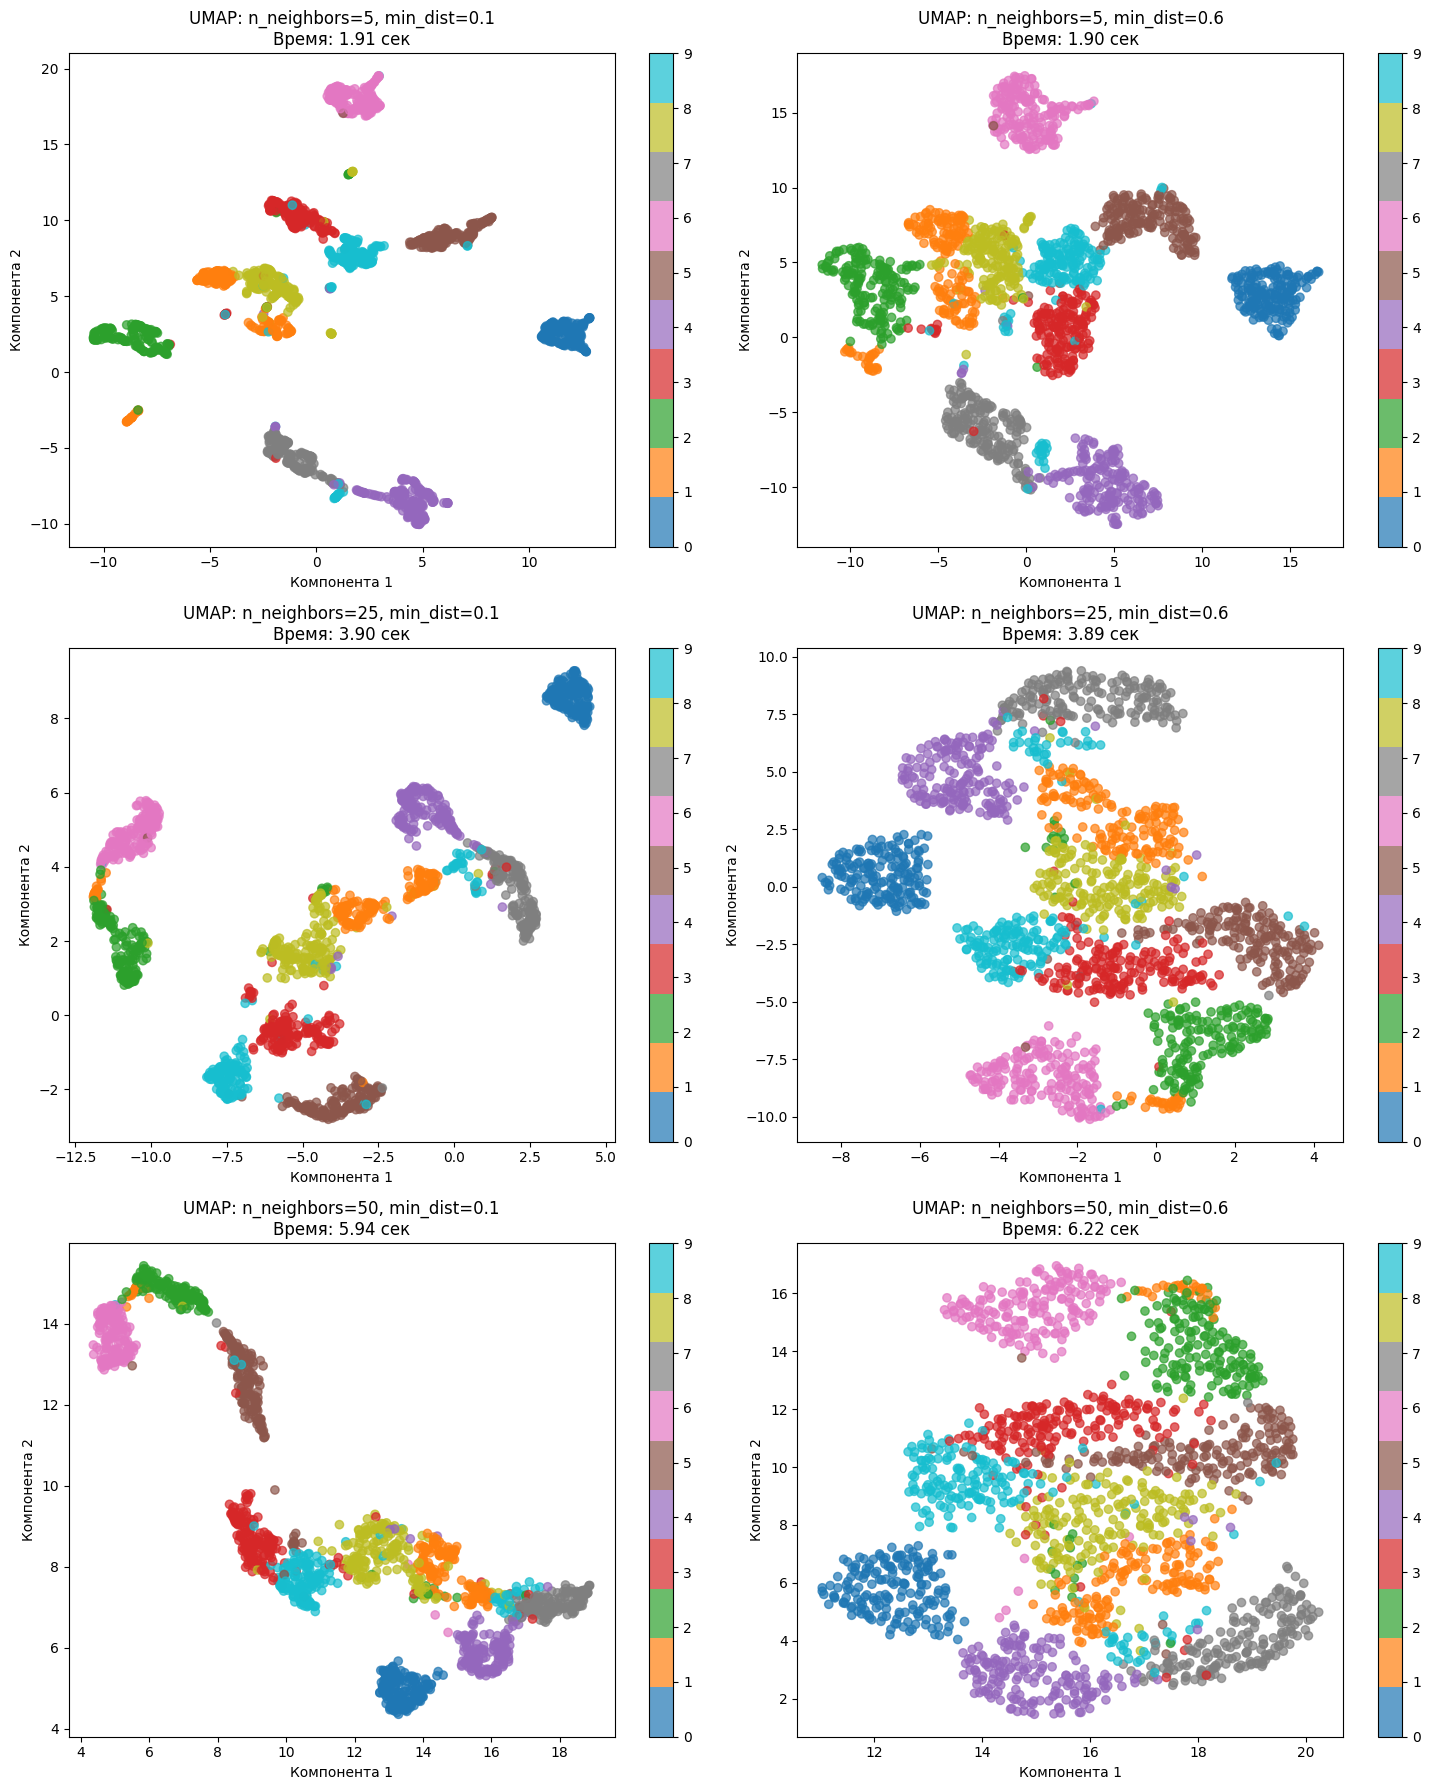

In [56]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
import time


digits = datasets.load_digits()
X = digits.data
y = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_neighbors_list = [5, 25, 50]
min_dist_list = [0.1, 0.6]

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.ravel()

index = 0
for n_neighbors in n_neighbors_list:
    for min_dist in min_dist_list:
        start_time = time.time()
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
        X_umap = reducer.fit_transform(X_scaled)
        umap_time = time.time() - start_time
        
        scatter = axes[index].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', alpha=0.7)
        axes[index].set_title(f'UMAP: n_neighbors={n_neighbors}, min_dist={min_dist}\nВремя: {umap_time:.2f} сек')
        axes[index].set_xlabel('Компонента 1')
        axes[index].set_ylabel('Компонента 2')
        plt.colorbar(scatter, ax=axes[index])
        
        index += 1

plt.tight_layout()
plt.show()